# **Model Engineering para Previsão de Churn** 🛠️

# 📥 1. Carregamento e Preparação Inicial da Base

Nesta etapa, a base de dados será carregada e algumas transformações iniciais serão aplicadas para preparar o conjunto de dados para a engenharia de atributos.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [4]:
df[['Tenure Months', 'Monthly Charges', 'Total Charges']].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


💡 **Observação:**

A base foi carregada com sucesso e a variável `Total Charges` foi convertida para formato numérico, tratando registros inválidos como valores ausentes. Esse ajuste é necessário para garantir consistência nas próximas etapas de engenharia de atributos e modelagem.

# 🧩 2. Feature Engineering

Nesta etapa, serão criadas novas variáveis derivadas a partir das informações originais da base, com o objetivo de capturar padrões adicionais que possam melhorar o desempenho dos modelos.

In [5]:
service_cols = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

df['services_count'] = (
    (df[service_cols] != 'No').sum(axis=1)
)

df['has_online_security_backup'] = np.where(
    (df['Online Security'] == 'Yes') | (df['Online Backup'] == 'Yes'),
    1, 0
)

df['is_senior_alone'] = np.where(
    (df['Senior Citizen'] == 'Yes') & (df['Partner'] == 'No') & (df['Dependents'] == 'No'),
    1, 0
)

df['monthly_charge_per_tenure'] = df['Monthly Charges'] / (df['Tenure Months'] + 1)

df['is_long_contract'] = np.where(
    df['Contract'].isin(['One year', 'Two year']),
    1, 0
)

In [6]:
novas_features = [
    'services_count',
    'has_online_security_backup',
    'is_senior_alone',
    'monthly_charge_per_tenure',
    'is_long_contract'
]

df[novas_features].head()

,services_count,has_online_security_backup,is_senior_alone,monthly_charge_per_tenure,is_long_contract
0,4,1,0,17.950000,0
1,2,0,0,23.566667,0
2,6,0,0,11.072222,0
3,7,0,0,3.613793,0
4,7,1,0,2.074000,0


In [7]:
df[novas_features].describe()

,services_count,has_online_security_backup,is_senior_alone,monthly_charge_per_tenure,is_long_contract
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,5.543092,0.471674,0.079228,5.770645,0.449808
std,1.892963,0.499232,0.270113,8.722435,0.497510
min,2.000000,0.000000,0.000000,0.264384,0.000000
25%,4.000000,0.000000,0.000000,1.250000,0.000000
50%,6.000000,0.000000,0.000000,2.075926,0.000000
75%,7.000000,1.000000,0.000000,5.946429,1.000000
max,9.000000,1.000000,1.000000,80.850000,1.000000


💡 **Observação:**

Foram criadas novas variáveis derivadas com o objetivo de representar melhor o perfil e o comportamento dos clientes. Entre elas, destacam-se a contagem de serviços contratados, indicadores de proteção digital, perfil de cliente idoso sem apoio familiar, relação entre cobrança mensal e tempo de permanência, e sinalização de contratos de longo prazo.

Essas novas features podem contribuir para capturar padrões que não estão explicitamente representados nas variáveis originais, aumentando o potencial preditivo dos modelos nas próximas etapas.

In [8]:
df.groupby('Churn Value')[novas_features].mean()

,services_count,has_online_security_backup,is_senior_alone,monthly_charge_per_tenure,is_long_contract
Churn Value,,,,,
0,5.910707,0.506958,0.055083,3.612215,0.570932
1,4.525415,0.373997,0.146067,11.745880,0.114500


💡 **Observação:**

A análise das novas features por classe de churn evidencia diferenças relevantes entre clientes que permaneceram e aqueles que cancelaram o serviço.

Clientes que não realizaram churn apresentam, em média, maior número de serviços contratados (`services_count`), maior presença de mecanismos de proteção digital (`has_online_security_backup`) e maior proporção de contratos de longo prazo (`is_long_contract`). Esses fatores indicam maior engajamento e vínculo com a empresa.

Por outro lado, clientes que realizaram churn apresentam maior valor na variável `monthly_charge_per_tenure`, sugerindo um custo relativo mais elevado em relação ao tempo de permanência, o que pode indicar insatisfação ou menor percepção de valor ao longo do tempo.

Além disso, a variável `is_senior_alone` apresenta valores mais altos entre clientes que cancelaram, indicando que esse perfil pode estar mais suscetível ao churn.

De forma geral, as features criadas demonstram potencial explicativo relevante e podem contribuir significativamente para melhorar o desempenho dos modelos nas próximas etapas.

# 🧹 3. Preparação para Modelagem

Nesta etapa, será definido o conjunto de variáveis explicativas e a variável alvo, além da separação entre treino e teste e da construção do pipeline de pré-processamento para as próximas etapas de modelagem.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [10]:
y = df['Churn Value']
y.value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [11]:
colunas_excluir = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

X = df.drop(columns=colunas_excluir)

In [13]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

X.head()

Dimensão de X: (7043, 26)
Dimensão de y: (7043,)


,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,services_count,has_online_security_backup,is_senior_alone,monthly_charge_per_tenure,is_long_contract
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,...,Month-to-month,Yes,Mailed check,53.85,108.15,4,1,0,17.950000,0
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,...,Month-to-month,Yes,Electronic check,70.70,151.65,2,0,0,23.566667,0
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,99.65,820.50,6,0,0,11.072222,0
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,104.80,3046.05,7,0,0,3.613793,0
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,7,1,0,2.074000,0


In [14]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Colunas numéricas:")
print(numeric_features)

print("\nColunas categóricas:")
print(categorical_features)

Colunas numéricas:
['Zip Code', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'services_count', 'has_online_security_backup', 'is_senior_alone', 'monthly_charge_per_tenure', 'is_long_contract']

Colunas categóricas:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 26)
X_test: (1409, 26)
y_train: (5634,)
y_test: (1409,)


In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [18]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

💡 **Observação:**

A base foi preparada com sucesso para a etapa de modelagem, mantendo a variável alvo `Churn Value` com distribuição desbalanceada (aproximadamente 73% não churn e 27% churn), característica comum em problemas reais de retenção de clientes.

O conjunto de variáveis explicativas resultante possui 26 colunas, incluindo tanto variáveis originais quanto as novas features criadas na etapa de engenharia de atributos, ampliando o potencial preditivo do modelo.

As variáveis foram corretamente separadas entre numéricas e categóricas, permitindo a aplicação de técnicas apropriadas de pré-processamento, como padronização e codificação.

A divisão entre treino e teste foi realizada com estratificação, garantindo a preservação da proporção entre as classes em ambos os conjuntos, o que é essencial para avaliações consistentes e comparáveis entre modelos.

De forma geral, o dataset encontra-se estruturado e pronto para a aplicação de técnicas de seleção de features e treinamento de múltiplos algoritmos.

# 🎯 4. Seleção de Features e Treinamento de Múltiplos Modelos
Nesta etapa, será aplicada uma técnica de seleção de atributos para reduzir dimensionalidade e destacar variáveis mais relevantes, seguida do treinamento de diferentes algoritmos de classificação para comparação de desempenho.

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [22]:
selector = SelectKBest(score_func=f_classif, k=20)

X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

In [23]:
print("Antes da seleção:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

print("\nDepois da seleção:")
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

Antes da seleção:
X_train_processed: (5634, 1180)
X_test_processed: (1409, 1180)

Depois da seleção:
X_train_selected: (5634, 20)
X_test_selected: (1409, 20)


In [24]:
feature_names = preprocessor.get_feature_names_out()
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]

print("Features selecionadas:")
for feature in selected_features:
    print(feature)

Features selecionadas:
num__Tenure Months
num__services_count
num__monthly_charge_per_tenure
num__is_long_contract
cat__Dependents_No
cat__Dependents_Yes
cat__Internet Service_Fiber optic
cat__Online Security_No
cat__Online Security_No internet service
cat__Online Backup_No
cat__Online Backup_No internet service
cat__Device Protection_No
cat__Device Protection_No internet service
cat__Tech Support_No
cat__Tech Support_No internet service
cat__Streaming TV_No internet service
cat__Streaming Movies_No internet service
cat__Contract_Month-to-month
cat__Contract_Two year
cat__Payment Method_Electronic check


💡 **Observação:**

Foi aplicada a técnica **SelectKBest** com base no teste estatístico ANOVA (`f_classif`) para selecionar as variáveis mais relevantes para o problema de churn.

Essa etapa tem como objetivo reduzir a dimensionalidade após o pré-processamento, destacando os atributos com maior potencial discriminativo e contribuindo para modelos mais eficientes e interpretáveis.

Além disso, a identificação das features selecionadas permite analisar quais variáveis originais e derivadas se mostram mais relevantes para a previsão de churn.

In [25]:
modelos = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob):
    resultados = {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

    print(f"\nModelo: {nome_modelo}")
    print(f"Accuracy: {resultados['accuracy']:.4f}")
    print(f"Precision: {resultados['precision']:.4f}")
    print(f"Recall: {resultados['recall']:.4f}")
    print(f"F1-score: {resultados['f1_score']:.4f}")
    print(f"ROC-AUC: {resultados['roc_auc']:.4f}")
    print(f"PR-AUC: {resultados['pr_auc']:.4f}")

    return resultados

In [28]:
resultados_modelos = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_selected, y_train)
    
    y_pred = modelo.predict(X_test_selected)
    y_prob = modelo.predict_proba(X_test_selected)[:, 1]
    
    resultado = avaliar_modelo(nome, y_test, y_pred, y_prob)
    resultados_modelos.append(resultado)


Modelo: Decision Tree
Accuracy: 0.7353
Precision: 0.5013
Recall: 0.5160
F1-score: 0.5086
ROC-AUC: 0.6707
PR-AUC: 0.3921

Modelo: Random Forest
Accuracy: 0.7729
Precision: 0.5860
Recall: 0.4920
F1-score: 0.5349
ROC-AUC: 0.7996
PR-AUC: 0.5908

Modelo: SVM
Accuracy: 0.8013
Precision: 0.6469
Recall: 0.5535
F1-score: 0.5965
ROC-AUC: 0.8049
PR-AUC: 0.6049

Modelo: Gradient Boosting
Accuracy: 0.8027
Precision: 0.6558
Recall: 0.5401
F1-score: 0.5924
ROC-AUC: 0.8516
PR-AUC: 0.6674


In [29]:
df_resultados_modelos = pd.DataFrame(resultados_modelos)
df_resultados_modelos.round(4).sort_values(by='f1_score', ascending=False)

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
2,SVM,0.8013,0.6469,0.5535,0.5965,0.8049,0.6049
3,Gradient Boosting,0.8027,0.6558,0.5401,0.5924,0.8516,0.6674
1,Random Forest,0.7729,0.5860,0.4920,0.5349,0.7996,0.5908
0,Decision Tree,0.7353,0.5013,0.5160,0.5086,0.6707,0.3921


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

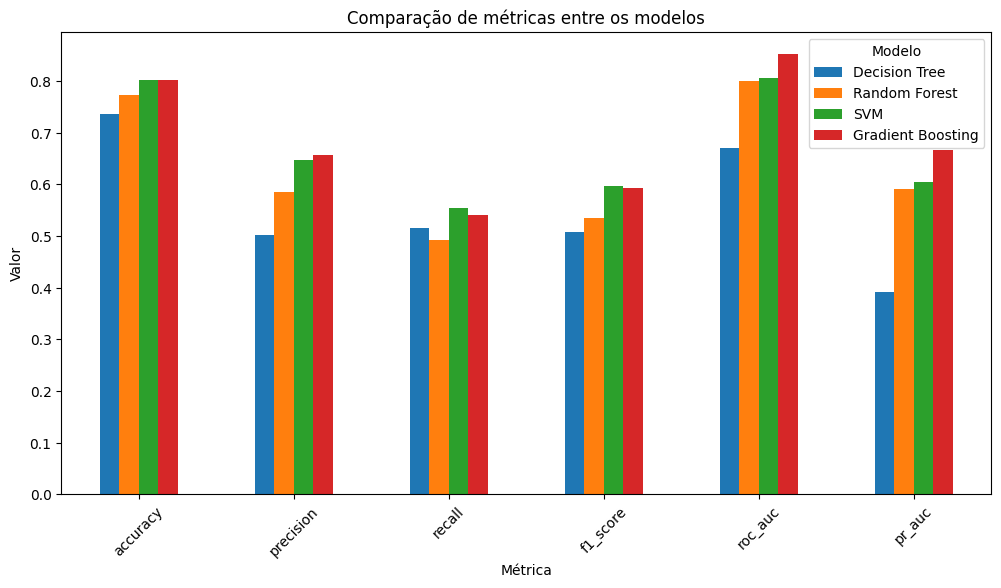

In [33]:
metricas_plot = df_resultados_modelos.set_index('modelo')[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']]

metricas_plot.T.plot(kind='bar', figsize=(12,6))
plt.title('Comparação de métricas entre os modelos')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.xticks(rotation=45)
plt.legend(title='Modelo')
plt.show()

💡 **Observação:**

A comparação entre os modelos evidencia que o algoritmo **Gradient Boosting** apresentou o melhor desempenho geral, destacando-se especialmente nas métricas ROC-AUC, PR-AUC e F1-score.

Essas métricas são particularmente relevantes para problemas de churn, devido ao desbalanceamento entre as classes e à necessidade de identificar corretamente clientes com maior probabilidade de cancelamento.

Embora outros modelos, como SVM e Random Forest, tenham apresentado resultados competitivos, o Gradient Boosting demonstrou melhor capacidade de generalização e separação entre as classes, sendo selecionado como o modelo mais adequado para as etapas seguintes de ajuste e otimização.

# ⚙️ 5. Ajuste Fino do Melhor Modelo

Nesta etapa, será realizado o ajuste de hiperparâmetros do modelo selecionado, com o objetivo de buscar uma configuração que maximize seu desempenho no problema de churn.

💡 **Objetivo do tuning:**

Após a comparação entre diferentes algoritmos, o modelo **Gradient Boosting** foi selecionado como o mais promissor. Nesta etapa, será realizada uma busca por combinações de hiperparâmetros para identificar configurações capazes de melhorar seu desempenho, especialmente em métricas relevantes para churn, como F1-score, ROC-AUC e PR-AUC.

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
gb_model = GradientBoostingClassifier(random_state=42)

In [36]:
param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

In [38]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [39]:
grid_search.fit(X_train_selected, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 150], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [40]:
print("Melhores parâmetros:")
print(grid_search.best_params_)

Melhores parâmetros:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [42]:
print("Melhor F1-score na validação cruzada:")
print(grid_search.best_score_)

Melhor F1-score na validação cruzada:
0.5973683104801201


In [43]:
best_gb_model = grid_search.best_estimator_

In [44]:
y_pred_best_gb = best_gb_model.predict(X_test_selected)
y_prob_best_gb = best_gb_model.predict_proba(X_test_selected)[:, 1]

In [45]:
resultado_best_gb = avaliar_modelo("Gradient Boosting Tunado", y_test, y_pred_best_gb, y_prob_best_gb)


Modelo: Gradient Boosting Tunado
Accuracy: 0.8006
Precision: 0.6505
Recall: 0.5374
F1-score: 0.5886
ROC-AUC: 0.8492
PR-AUC: 0.6655


In [47]:
from sklearn.metrics import confusion_matrix, classification_report

In [48]:
cm_best_gb = confusion_matrix(y_test, y_pred_best_gb)
cm_best_gb

array([[927, 108],
       [173, 201]])

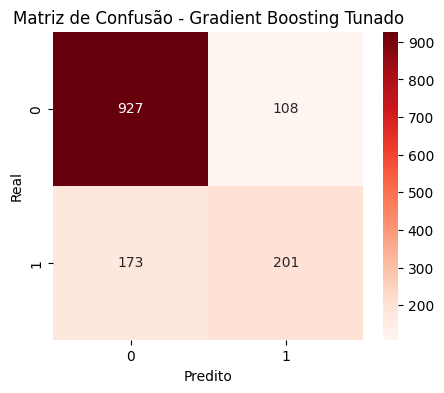

In [49]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_best_gb, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão - Gradient Boosting Tunado')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [50]:
print(classification_report(y_test, y_pred_best_gb, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [51]:
comparacao_final = pd.DataFrame([
    df_resultados_modelos[df_resultados_modelos['modelo'] == 'Gradient Boosting'].iloc[0].to_dict(),
    resultado_best_gb
])

comparacao_final.round(4)

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gradient Boosting,0.8027,0.6558,0.5401,0.5924,0.8516,0.6674
1,Gradient Boosting Tunado,0.8006,0.6505,0.5374,0.5886,0.8492,0.6655


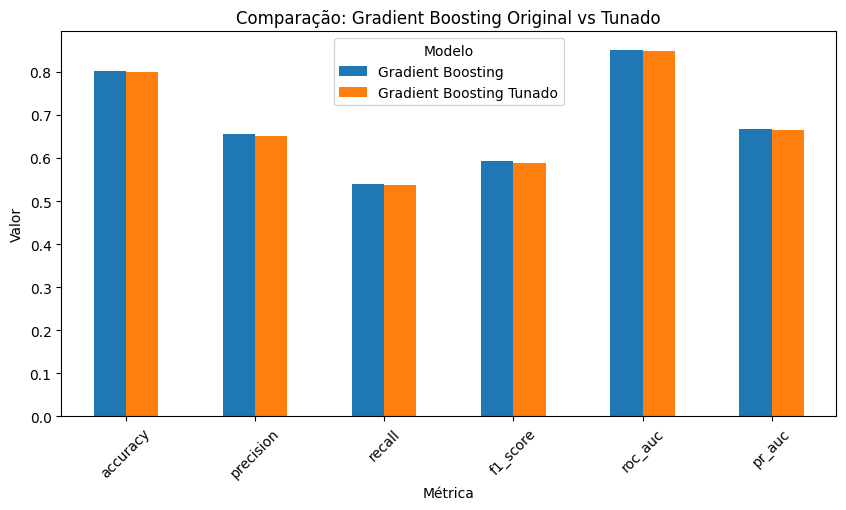

In [52]:
metricas_tuning = comparacao_final.set_index('modelo')[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']]

metricas_tuning.T.plot(kind='bar', figsize=(10,5))
plt.title('Comparação: Gradient Boosting Original vs Tunado')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.xticks(rotation=45)
plt.legend(title='Modelo')
plt.show()

💡 **Observação:**

Foi realizado o ajuste de hiperparâmetros do modelo Gradient Boosting utilizando `GridSearchCV` com validação cruzada e F1-score como métrica principal.

A melhor combinação encontrada foi `learning_rate=0.1`, `max_depth=3`, `n_estimators=100` e `subsample=0.8`, com F1-score médio de aproximadamente 0,597 na validação cruzada.

No entanto, ao comparar o modelo tunado com a versão original no conjunto de teste, observou-se que o desempenho final permaneceu muito próximo, com leve vantagem para o modelo original em métricas como accuracy, F1-score, ROC-AUC e PR-AUC.

Esse resultado indica que o ajuste de hiperparâmetros não trouxe ganho efetivo de desempenho nesta etapa, sugerindo que a configuração inicial do Gradient Boosting já apresentava um bom equilíbrio para o problema analisado. Dessa forma, o modelo original foi mantido como a melhor escolha para continuidade do projeto.

# 🏁 6. Conclusão

Nesta etapa, foram realizadas ações de engenharia de atributos, preparação dos dados, seleção de features, comparação entre diferentes algoritmos e ajuste fino do modelo de melhor desempenho.

As novas features criadas mostraram potencial explicativo relevante, especialmente em relação a engajamento com serviços, perfil contratual e custo relativo ao tempo de permanência.

Entre os modelos testados, o **Gradient Boosting** apresentou o melhor desempenho geral, destacando-se em métricas importantes para o problema de churn, como F1-score, ROC-AUC e PR-AUC.

Embora o ajuste de hiperparâmetros tenha sido realizado, o modelo tunado não superou a versão original no conjunto de teste. Assim, o **Gradient Boosting original** foi mantido como melhor modelo desta etapa.

Os resultados obtidos indicam que a base possui bom potencial preditivo e fornecem uma base sólida para as próximas fases do projeto, como redes neurais, API e documentação final.

# 📊 7. Registro de Experimentos com MLflow

Nesta etapa, os resultados do model engineering serão registrados no MLflow, permitindo rastrear parâmetros, métricas e artefatos do melhor modelo selecionado.

In [53]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

In [54]:
mlflow.set_experiment("churn_model_engineering")

2026/03/31 21:16:55 INFO mlflow.tracking.fluent: Experiment with name 'churn_model_engineering' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/necca/OneDrive/Documentos/projeto_ml01/notebooks/mlruns/2', creation_time=1775002615890, experiment_id='2', last_update_time=1775002615890, lifecycle_stage='active', name='churn_model_engineering', tags={}, workspace='default'>

In [56]:
Path("artifacts").mkdir(exist_ok=True)

In [57]:
def salvar_matriz_confusao(cm, titulo, nome_arquivo, cmap='Blues'):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(titulo)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    caminho = Path("artifacts") / nome_arquivo
    plt.savefig(caminho)
    plt.close()
    return str(caminho)

In [59]:
cm_gb = confusion_matrix(y_test, modelos["Gradient Boosting"].predict(X_test_selected))

with mlflow.start_run(run_name="GradientBoosting_Original"):

    mlflow.log_param("model_name", "GradientBoosting")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 20)
    mlflow.log_param("random_state", 42)

    resultado_gb = df_resultados_modelos[df_resultados_modelos['modelo'] == 'Gradient Boosting'].iloc[0].to_dict()

    mlflow.log_metric("accuracy", resultado_gb["accuracy"])
    mlflow.log_metric("precision", resultado_gb["precision"])
    mlflow.log_metric("recall", resultado_gb["recall"])
    mlflow.log_metric("f1_score", resultado_gb["f1_score"])
    mlflow.log_metric("roc_auc", resultado_gb["roc_auc"])
    mlflow.log_metric("pr_auc", resultado_gb["pr_auc"])

    caminho_cm_gb = salvar_matriz_confusao(
        cm_gb,
        "Matriz de Confusão - Gradient Boosting Original",
        "cm_gradient_boosting_original.png",
        cmap='Greens'
    )
    mlflow.log_artifact(caminho_cm_gb)

    mlflow.sklearn.log_model(modelos["Gradient Boosting"], "gradient_boosting_model")

2026/03/31 21:18:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 21:18:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [60]:
with mlflow.start_run(run_name="GradientBoosting_Tuned"):

    mlflow.log_param("model_name", "GradientBoosting_Tuned")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 20)
    mlflow.log_param("random_state", 42)

    for param, value in grid_search.best_params_.items():
        mlflow.log_param(param, value)

    mlflow.log_metric("accuracy", resultado_best_gb["accuracy"])
    mlflow.log_metric("precision", resultado_best_gb["precision"])
    mlflow.log_metric("recall", resultado_best_gb["recall"])
    mlflow.log_metric("f1_score", resultado_best_gb["f1_score"])
    mlflow.log_metric("roc_auc", resultado_best_gb["roc_auc"])
    mlflow.log_metric("pr_auc", resultado_best_gb["pr_auc"])

    caminho_cm_best_gb = salvar_matriz_confusao(
        cm_best_gb,
        "Matriz de Confusão - Gradient Boosting Tunado",
        "cm_gradient_boosting_tuned.png",
        cmap='Reds'
    )
    mlflow.log_artifact(caminho_cm_best_gb)

    mlflow.sklearn.log_model(best_gb_model, "gradient_boosting_tuned_model")

2026/03/31 21:18:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 21:18:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


💡 **Observação:**

Os experimentos da etapa de model engineering foram registrados no MLflow, incluindo parâmetros, métricas e matrizes de confusão dos modelos selecionados.

Esse registro permite rastrear a evolução do projeto de forma estruturada, facilitando a comparação entre o modelo original e o modelo tunado, além de documentar os resultados obtidos para futuras etapas, como redes neurais e deployment.